In [1]:
# W4D2: Bias-Variance Tradeoff & Regularisation

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Create dataset
X, y = make_regression(
    n_samples=200,
    n_features=5,
    noise=25,
    random_state=42
)

# Convert to DataFrame
df = pd.DataFrame(X, columns=[
    "Feature1",
    "Feature2",
    "Feature3",
    "Feature4",
    "Feature5"
])

df["Target"] = y

print(df.head())

   Feature1  Feature2  Feature3  Feature4  Feature5      Target
0 -0.385314  0.199060 -0.600217  0.462103  0.069802  -16.683791
1  0.130741  1.632411 -1.430141 -1.247783 -0.440044 -119.642066
2 -0.773010  0.224092  0.012592 -0.401220  0.097676   31.446423
3 -0.576771 -0.050238 -0.238948  0.270457 -0.907564  -50.314809
4 -0.575818  0.614167  0.757508 -0.220970 -0.530501   38.780687


In [2]:
# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [3]:
linear = LinearRegression()

linear.fit(X_train, y_train)

pred_linear = linear.predict(X_test)

print("Linear Regression")
print("R2 Score:", r2_score(y_test, pred_linear))
print("MSE:", mean_squared_error(y_test, pred_linear))

Linear Regression
R2 Score: 0.93973544052506
MSE: 531.6147639266085


In [4]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

pred_ridge = ridge.predict(X_test)

print("\nRidge Regression")
print("R2 Score:", r2_score(y_test, pred_ridge))
print("MSE:", mean_squared_error(y_test, pred_ridge))


Ridge Regression
R2 Score: 0.9401894063330329
MSE: 527.6101727051844


In [5]:
lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

pred_lasso = lasso.predict(X_test)

print("\nLasso Regression")
print("R2 Score:", r2_score(y_test, pred_lasso))
print("MSE:", mean_squared_error(y_test, pred_lasso))


Lasso Regression
R2 Score: 0.9398553394924706
MSE: 530.5570931859539


In [6]:
results = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso"],
    "R2 Score": [
        r2_score(y_test, pred_linear),
        r2_score(y_test, pred_ridge),
        r2_score(y_test, pred_lasso)
    ],
    "MSE": [
        mean_squared_error(y_test, pred_linear),
        mean_squared_error(y_test, pred_ridge),
        mean_squared_error(y_test, pred_lasso)
    ]
})

print(results)

    Model  R2 Score         MSE
0  Linear  0.939735  531.614764
1   Ridge  0.940189  527.610173
2   Lasso  0.939855  530.557093


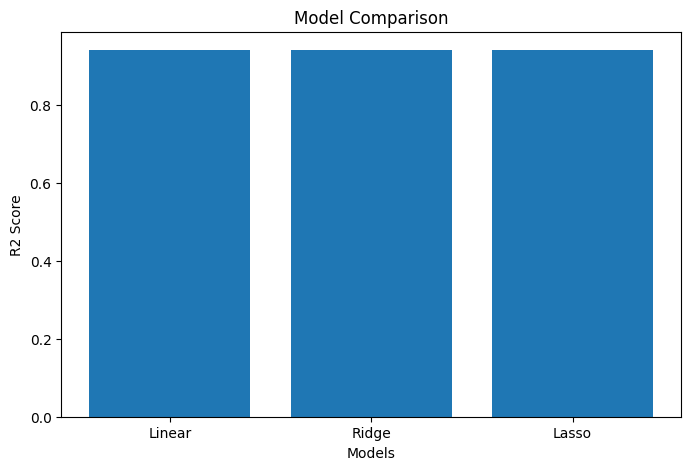

In [7]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["R2 Score"])

plt.title("Model Comparison")

plt.xlabel("Models")

plt.ylabel("R2 Score")

plt.show()

In [8]:
def practice():
    print("Bias-Variance Tradeoff & Regularisation")

    models = {
        "Linear": LinearRegression(),
        "Ridge": Ridge(alpha=1),
        "Lasso": Lasso(alpha=0.1)
    }

    for name, model in models.items():

        model.fit(X_train, y_train)

        prediction = model.predict(X_test)

        print("\n", name)

        print("R2:", round(r2_score(y_test, prediction), 3))

        print("MSE:", round(mean_squared_error(y_test, prediction), 3))

practice()

print("Done! Review with CIA for feedback.")

Bias-Variance Tradeoff & Regularisation

 Linear
R2: 0.94
MSE: 531.615

 Ridge
R2: 0.94
MSE: 527.61

 Lasso
R2: 0.94
MSE: 530.557
Done! Review with CIA for feedback.


In [9]:
Ridge(alpha=0.1)

Ridge(alpha=0.1)

In [10]:
Ridge(alpha=1)

Ridge(alpha=1)

In [11]:
Ridge(alpha=10)

Ridge(alpha=10)

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_pipeline.fit(X_train, y_train)

pred = ridge_pipeline.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))

R2 Score: 0.9401596925924908


In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "ridge__alpha": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(X_train, y_train)

print("Best Alpha:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Alpha: {'ridge__alpha': 0.1}
Best CV Score: 0.9289482765602777


In [14]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    ridge_pipeline,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(scores)
print("Average CV Score:", scores.mean())

[0.94770002 0.94851924 0.92328866 0.93480464 0.90149003]
Average CV Score: 0.9311605175305461


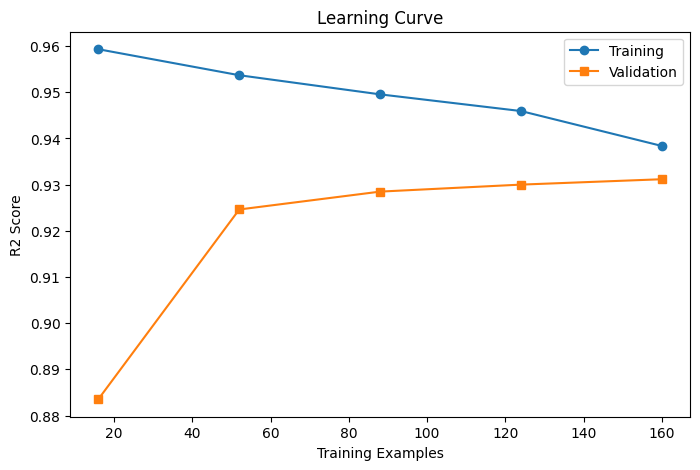

In [15]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    ridge_pipeline,
    X,
    y,
    cv=5,
    scoring="r2"
)

plt.figure(figsize=(8,5))

plt.plot(train_sizes,
         train_scores.mean(axis=1),
         marker="o",
         label="Training")

plt.plot(train_sizes,
         test_scores.mean(axis=1),
         marker="s",
         label="Validation")

plt.xlabel("Training Examples")
plt.ylabel("R2 Score")
plt.title("Learning Curve")

plt.legend()

plt.show()

In [17]:
coefficients = pd.DataFrame({
    "Feature": df.columns[:-1],
    "Coefficient": best_model.named_steps["ridge"].coef_
})

coefficients

,Feature,Coefficient
0,Feature1,2.442689
1,Feature2,11.566599
2,Feature3,64.314542
3,Feature4,18.774798
4,Feature5,66.060497
